In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import numpy as np
import scipy.stats as st
from astropy.io import fits
from astropy.table import Table
from data_analysis import *

# Random plot object because why not

In [2]:
class Plot:

    """
       Object for creating multiplots
       The plot starts with defining the main object
       To operate with a frame: open the frame, add as many things as you want, close frame
                                               (extra parts can be added later but the annotation will remain untouched)
       Figures can be saved or just showed
    """
    def __init__(self,nrows=1,ncols=1,name='',**kwargs):

        """
            nrows,ncols: integers > 0, the grid's dimensions
            name: string, the name of the whole figure
        """

        self.nrows = nrows
        self.ncols = ncols
        self.fig = plt.figure(**kwargs)
        self.fig.suptitle(name)

    #########################################################
    #                                                       #
    #                  FRAME OPERATIONS                     #
    #                                                       #
    #########################################################
    
    def open_frame(self,data,err=[],nplot=1,tit='',**kwargs):

        """ 
            opens a new subplot
            data: array-like, every data used in the frame must be given here
            err: array-like, preferably has the same amount of components as data
        
        """

        self.data = data
        self.err = err
        self.tit = tit
        self.fig.add_subplot(self.nrows,self.ncols,nplot,**kwargs)


    def close_frame(self,Legend=False,Grid=True,xLab='X',yLab='Y',xlim=[],ylim=[],xtick='default',ytick='default',**kwargs):

        """ adds all relevant annotation and closes subplot """
        
        frame = self.fig.gca()

        frame.set_title(self.tit)
        frame.set_xlabel(xLab)
        frame.set_ylabel(yLab)

        if len(np.asarray(xlim)) == 2:
            frame.set_xlim(xlim)

        if len(np.asarray(ylim)) == 2:
            frame.set_ylim(ylim)

        if xtick != 'default':
            frame.set_xticks(xtick)
        if ytick != 'default':
            frame.set_yticks(ytick)
        
        if Legend:
            frame.legend(**kwargs)

        if Grid:
            frame.grid()

        frame.xaxis.set_visible(True)
        frame.yaxis.set_visible(True)

    #########################################################
    #                                                       #
    #                   CREATING PLOTS                      #
    #                                                       #
    #########################################################
        
    def scatter(self,dataset=(0,1),errors=False,**kwargs):

        frame = self.fig.gca()
        
        X = self.data[dataset[0]]
        Y = self.data[dataset[1]]
        
        frame.scatter(X,Y,**kwargs)
        
        if errors:
            dX = self.err[dataset[0]]
            dY = self.err[dataset[1]]
            frame.errorbar(X,Y,xerr=dX,yerr=dY,ecolor='black',fmt='none')

        frame.xaxis.set_visible(False)   # hides ticks
        frame.yaxis.set_visible(False)   # hides ticks

    def plot(self, dataset=(0,1), errors=False,**kwargs):
        
        frame = self.fig.gca()
            
        X = self.data[dataset[0]]
        dX = self.err[dataset[0]]
        Y = self.data[dataset[1]]
        dY = self.err[dataset[1]]
        
        frame.plot(X,Y,**kwargs)
        
        if errors:
            frame.errorbar(X,Y,xerr=dX,yerr=dY,ecolor='black',fmt='none')

        frame.xaxis.set_visible(False)  # hides ticks
        frame.yaxis.set_visible(False)  # hides ticks

    def histo(self,dataset=0,**kwargs):

        frame = self.fig.gca()

        X = self.data[dataset]
        frame.hist(X,**kwargs)

        frame.xaxis.set_visible(False)  # hides ticks
        frame.yaxis.set_visible(False)  # hides ticks

    def image(self,dataset='full',cmap='jet',origin='lower',**kwargs):
        
        frame = self.fig.gca()
        
        if dataset != 'full':
            dat = self.data[dataset]
        else:
            dat = self.data
        
        self.im = frame.imshow(dat,cmap=cmap,origin=origin,**kwargs)


    #########################################################
    #                                                       #
    #               ADDITIONAL COMPONENTS                   #
    #                                                       #
    #########################################################

    def vLine(self,x,**kwargs):

        frame = self.fig.gca()
    
        frame.axvline(x,**kwargs)

    def lin_fit(self,slope,xy=(0,0),**kwargs):

        frame = self.fig.gca()

        frame.axline(xy1=xy,slope=slope,angle=0,**kwargs)

    def rectangle(self,xy1=(0,0),size=(0,0),angle=0,**kwargs):
        
        frame = self.fig.gca()
        frame.add_patch(ptc.Rectangle((xy1[0],xy1[1]),2*size[0],2*size[1],angle=angle,**kwargs))

    def oval(self,xy1=(0,0),size=(0,0),angle=0,**kwargs):
        
        frame = self.fig.gca()
        frame.add_patch(ptc.Ellipse(xy1,2*size[0],2*size[1],angle=angle,**kwargs))
        
    def cbar(self,**kwargs):
        frame = self.fig.gca()
        self.fig.colorbar(self.im,ax=frame,**kwargs)

    def spacing(self):
        self.fig.tight_layout()
        
    #########################################################
    #                                                       #
    #             EXPORTING/SHOWING THE PLOT                #
    #                                                       #
    #########################################################
    
    def save(self,filename='plot.png',**kwargs):
        self.fig.savefig(filename,**kwargs)

## Test cell

x1 = np.random.normal(0,1,100)
x2 = np.random.normal(0,1,100)

plot = Plot(figsize=(5,5),nrows=1,ncols=1,name='Összplot')

plot.open_frame(data=[x1,x2,x1,x2],err=[0.1,0.1,0.4,0.4])

plot.scatter(dataset=(1,0),errors=True,color='r',label='Plot1')
plot.oval(size=(1,2),fill=False,angle=-45)
plot.oval(size=(1,2),fill=False,angle=45)
plot.oval(size=(1,2),fill=False)
plot.oval(size=(1,2),fill=False,angle=90)
plot.oval(size=(1,1),color='b',alpha=0.5)

plot.close_frame(Legend=True,xlim=(-3,3),ylim=(-3,3))

plot.save('multiplots.png')

# Question 6.1 : FITS file analysis

In [14]:
img = fits.open('m101.fits')
print(img.info())
print()
print(f"There are 2 HDUs in the file")
print(f"The image data is in the first (0th as an index) HDU")

print('\n','-'*100,'\n')
for key in img[0].header[:10]:
    print(f"{key:.18s}: {img[0].header[key]}")
print('BITPIX value:',img[0].header['BITPIX'])
print('The datatype is int16, the value here is 16, the two correspond')

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
None

There are 2 HDUs in the file
The image data is in the first (0th as an index) HDU

 ---------------------------------------------------------------------------------------------------- 

SIMPLE: True
BITPIX: 16
NAXIS: 2
NAXIS1: 530
NAXIS2: 530
EXTEND: True
DATE: 06/02/02
ORIGIN: CASB -- STScI
PLTLABEL: E1409
PLATEID: 07PN
BITPIX value: 16
The datatype is int16, the value here is 16, the two correspond


In [4]:
dat = img[0].data
print(dat.shape)
if dat.shape == (530,530):
    print('Data shape and dimensions are the same')
print(img[0].header['NAXIS'])
print('The data has 2 axis as it can be seen from the tuple')
print(f'The datatype{dat.dtype} is basically {img[0].header["BITPIX"]} in string-code')

(530, 530)
Data shape and dimensions are the same
2
The data has 2 axis as it can be seen from the tuple
The datatype>i2 is basically 16 in string-code


min = 1507
max = 15752
std = 1848.2526085366376
mean = 4795.924268422927
median = 4102.0
mode = 3551


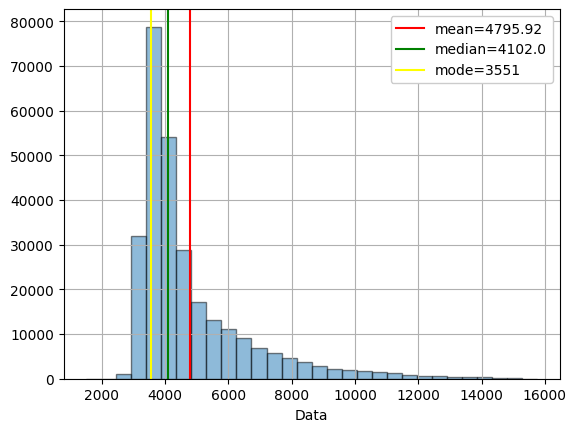

In [5]:
Q61 = Plot(ncols=1,nrows=1)
datflat = dat.flatten()

lines = [np.min(datflat),np.max(datflat),np.std(datflat),np.mean(datflat),np.median(datflat),st.mode(datflat).mode]
labels = ['min','max','std','mean','median','mode']

for i,j in zip(lines,labels):
    print(j,'=',i)
colors = ['','','','r','g','yellow']

Q61.open_frame(data=[datflat])

Q61.histo(bins=30,alpha=0.5,ec='black')

for i in range(3,len(lines)):
    Q61.vLine(lines[i],label=f"{labels[i]}={round(lines[i],2)}",color=colors[i])

Q61.close_frame(xLab='Data',yLab='',Legend=True,loc='upper right',framealpha=1)
Q61.save('Q61_1.png')

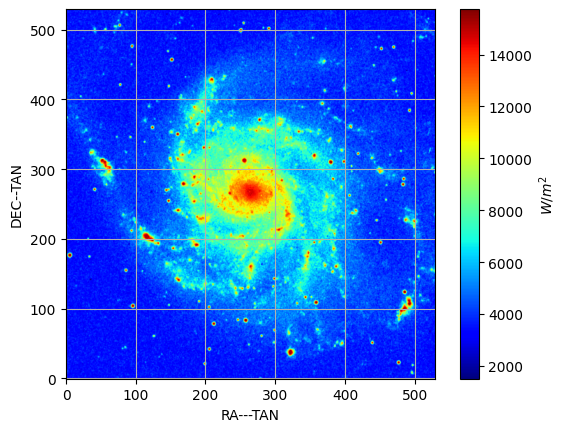

In [6]:
dat = np.asarray(dat,dtype=float)

Q61 = Plot(ncols=1,nrows=1)

Q61.open_frame(data=dat)
Q61.image()
Q61.cbar(label='$W/m^2$')
Q61.close_frame(xLab=img[0].header['CTYPE1'],yLab=img[0].header['CTYPE2'])
Q61.save('Q61_2.png')

In [15]:
img[0].header['BUNIT'] ='Counts'
newdat = fits.PrimaryHDU(datflat)
newdat.header = img[0].header
newdat.writeto('new_fits.fits', overwrite=True, output_verify='ignore')
img.close()

new = fits.open('new_fits.fits')
new[0].header

 [astropy.io.fits.verify]


SIMPLE  =                    T /FITS header                                     
BITPIX  =                   16 /No.Bits per pixel                               
NAXIS   =                    1 / No.dimensions                                  
NAXIS1  =               280900 / Length X axis                                  
EXTEND  =                    T /                                                
DATE    = '06/02/02          ' /Date of FITS file creation                      
ORIGIN  = 'CASB -- STScI     ' /Origin of FITS image                            
PLTLABEL= 'E1409             ' /Observatory plate label                         
PLATEID = '07PN              ' /GSSS Plate ID                                   
REGION  = 'XE133             ' /GSSS Region Name                                
DATE-OBS= '24/04/55          ' /UT date of Observation                          
UT      = '06:58:00.00       ' /UT time of observation                          
EPOCH   =  1.9553104248047E+

# Question 6.3 : Properties of a signal free area in an image

RMS: 3484.0414989874425
Mean: 3471.722222222222
STD: 292.7285062904905
RMS and STD have different calculation methods, thus differ
RMS is more similar to the mean than to the std, thus RMS is better at quantifying


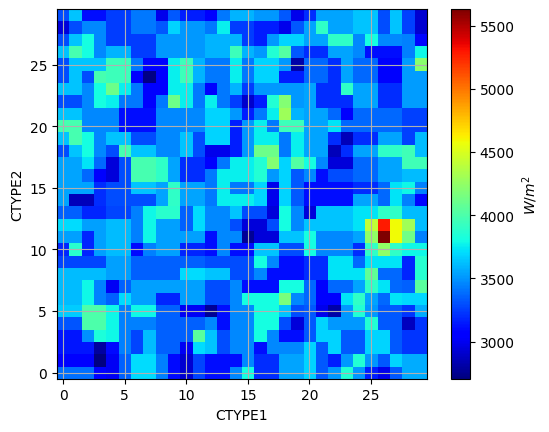

In [8]:
size=30
xy=[20,20]

area = dat[xy[0]:xy[0]+size,xy[1]:xy[1]+size]

Q63 = Plot(ncols=1,nrows=1)
Q63.open_frame(data=area)
Q63.image()
Q63.cbar(label='$W/m^2$')
Q63.close_frame(xLab='CTYPE1',yLab='CTYPE2')
Q63.save('Q63.png')

area = area.flatten()
RMS = np.sqrt(1/area.size*sum(area**2))

print('RMS:',RMS)
print('Mean:',np.mean(area))
print('STD:',np.std(area))
print('RMS and STD have different calculation methods, thus differ')
print('RMS is more similar to the mean than to the std, thus RMS is better at quantifying')

# Question 6.5 : Image stack and noise reduction

STD of the first image: 9.98401556679484
STD of the second image: 10.003955116338458
STD of the third image: 9.995349488722516
STD of the Mean image: 5.773191380233297
STD of the mean image using a different method: 5.770294583366139


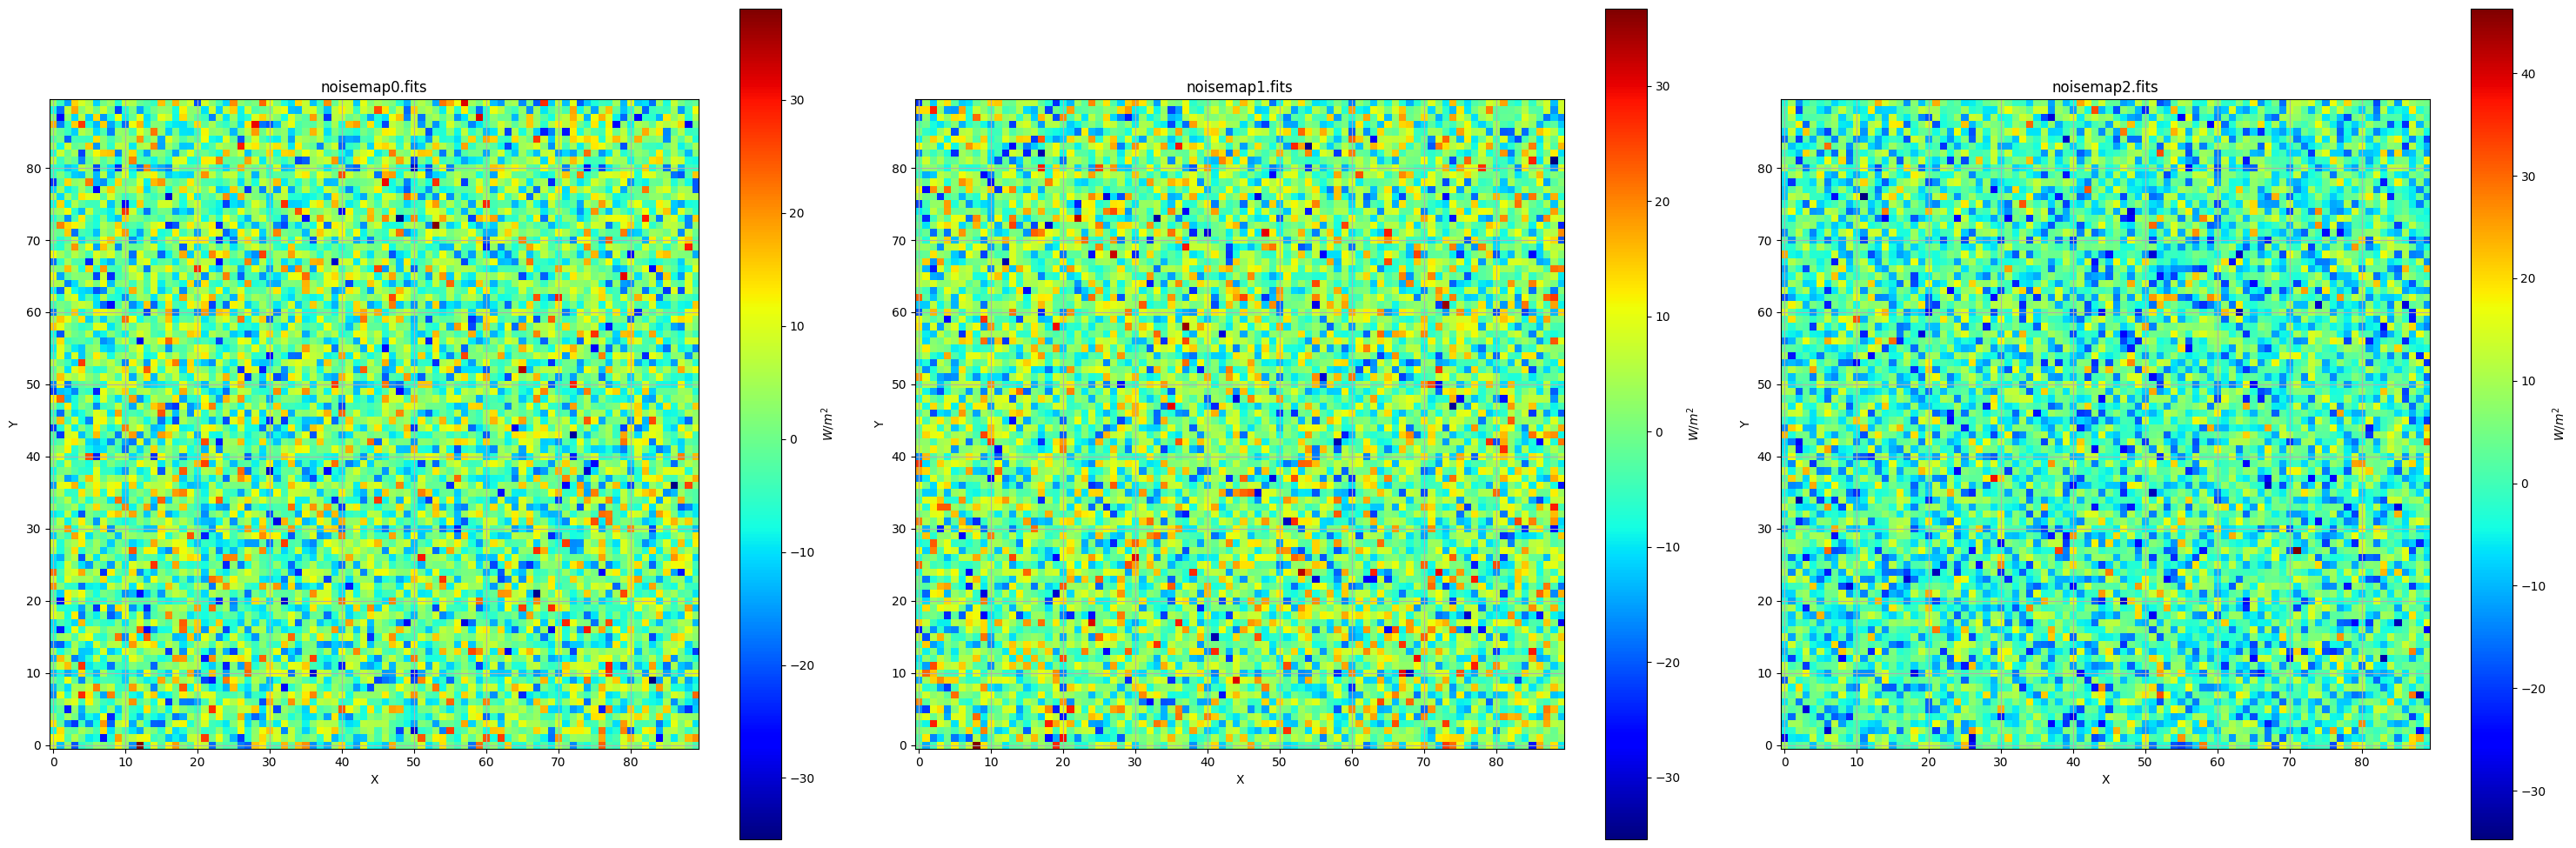

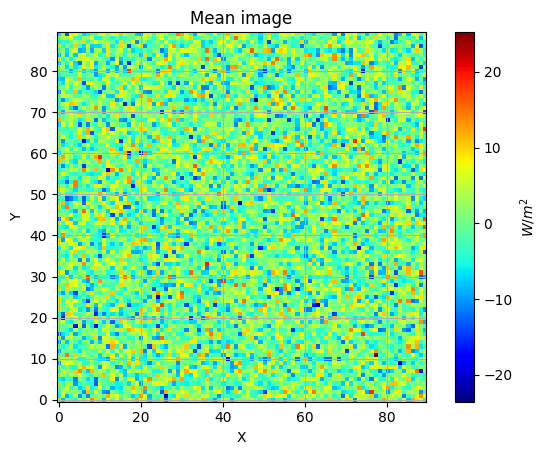

In [9]:
img1 = fits.open('noisemap0.fits')[0].data
img2 = fits.open('noisemap1.fits')[0].data
img3 = fits.open('noisemap2.fits')[0].data

std1 = np.std(img1.flatten())
std2 = np.std(img2.flatten())
std3 = np.std(img3.flatten())
print('STD of the first image:',std1)
print('STD of the second image:',std2)
print('STD of the third image:',std3)

IMG = np.stack([img1,img2,img3])

IMG_mean = np.mean(IMG,axis=0)


Q65 = Plot(ncols=3,nrows=1,figsize=(30,10))

Q65.open_frame(data=img1[::10,::10],nplot=1,tit='noisemap0.fits')
Q65.image()
Q65.cbar(label='$W/m^2$')
Q65.close_frame()

Q65.open_frame(data=img2[::10,::10],nplot=2,tit='noisemap1.fits')
Q65.image()
Q65.cbar(label='$W/m^2$')
Q65.close_frame()

Q65.open_frame(data=img3[::10,::10],nplot=3,tit='noisemap2.fits')
Q65.image()
Q65.cbar(label='$W/m^2$')
Q65.close_frame()

Q65.spacing()
Q65.save('Q65.png')

Q65 = Plot()
Q65.open_frame(data=IMG_mean[::10,::10],tit='Mean image')
Q65.image()
Q65.cbar(label='$W/m^2$')
Q65.close_frame()

Q65.spacing()
Q65.save('Q65_2.png')

print('STD of the Mean image:',np.std(IMG_mean.flatten()))
# Calculating the mean std manually:
Mean_std = 1/3*np.sqrt(std1**2+std2**2+std3**2)
print('STD of the mean image using a different method:',Mean_std)

# Question 6.6 : FITS Table and table modification

In [10]:
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

sf = (data["STARFLAG"] == 0)                              # STARFLAG == 0
af = (data["ASPCAPFLAG"] == 0)
snr = (data["SNR"] > 10)

##################################################
err = (data["GAIAEDR3_PARALLAX"]/data["GAIAEDR3_PARALLAX_ERROR"] > 5)  # IMPORTANT after multiple trial-errors the 
                                                                         #  limit is set to 200 because 5 caused a chaotic result (attached)
                                                                         #  this way the diagram looks as the one wanted
####################################################

g = (~np.isnan(data["GAIAEDR3_PHOT_G_MEAN_MAG"]))
bp = (~np.isnan(data["GAIAEDR3_PHOT_BP_MEAN_MAG"]))
rp = (~np.isnan(data["GAIAEDR3_PHOT_RP_MEAN_MAG"]))

mask = sf & af & snr & err & g & bp & rp

dataflag = []

for element in mask:
    if element:
        dataflag.append(1)
    else:
        dataflag.append(0)
dataflag = np.array(dataflag)


data = Table(data)
data['DATAFLAG'] = dataflag

def Mg(mg,par):
    return mg+5*np.log10(par/1000)+5

magni = []
for element,p,g in zip(dataflag,data['GAIAEDR3_PARALLAX'],data['GAIAEDR3_PHOT_G_MEAN_MAG']):
    if element == 0:
        magni.append(-1)    
    else:
        magni.append(Mg(g,p))
        
data['BUNIT'] = magni

data.write('APOGEE_update.fits',overwrite = True)

# Question 6.7 : Exploring GAIA data

The maximum g flux value is 42489404.0
The corresponding row is is:
      source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64  17418337.0  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
------------------------------
m_0 = 25.69 m


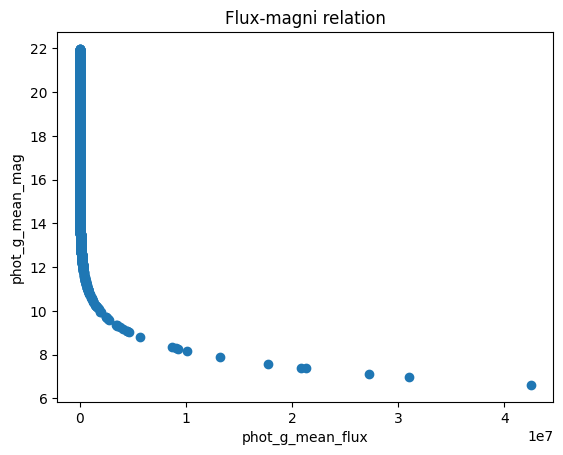

In [11]:
import pandas as pd
import numpy as np

headers = np.loadtxt('gaiaTestData.csv', delimiter=',',max_rows=1,dtype=str)
values = np.loadtxt('gaiaTestData.csv', delimiter=',',skiprows=1,dtype=float)

data = pd.DataFrame(values,columns=headers)

g_fl_max = np.max(data['phot_g_mean_flux'])
print(f'The maximum g flux value is {g_fl_max}')
print(f'The corresponding row is is:\n {data[(data.phot_g_mean_flux == g_fl_max)]}')

data = data.sort_values('phot_g_mean_flux')

x = data['phot_g_mean_flux']
y = data['phot_g_mean_mag']

Q67 = Plot()
Q67.open_frame(data=(x,y),tit='Flux-magni relation')
Q67.scatter()
Q67.close_frame(xLab='phot_g_mean_flux',yLab='phot_g_mean_mag',Grid=False)

m0 = Method_Of_Least_Squares(np.log10(x),y).a()
print('-'*30)
print(f'm_0 = {m0:.2f} m')

# Question 6.10 : Retrieving data using astroquery

In [12]:
from astroquery.gaia import Gaia


simple_query = """
SELECT 
    source_id,
    ra, dec,
    parallax, parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
    
FROM gaiadr3.gaia_source

WHERE parallax / parallax_error > 5
AND
phot_g_mean_mag IS NOT NULL
AND
phot_bp_mean_mag IS NOT NULL
AND
phot_rp_mean_mag IS NOT NULL
"""

job = Gaia.launch_job(simple_query)
results = job.get_results()

extracted = results[np.random.randint(0,len(results)-1,50)]

data_gaia = extracted.to_pandas()

table = Table.from_pandas(data_gaia)
table.write('astroquery_gaia.fits',overwrite = True)

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.11.909) or chardet (4.0.0)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


# 6.8. More OOP practice

In [13]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    
    def __init__(self,first_terms = [0,1]):
        self.seq = first_terms
    
    def N(self,n):
        while len(self.seq) < n:
            self.seq.append(self.seq[-1]+self.seq[-2])
        return self.seq
    
    def N_M(self,n,m):
        sq = np.array(self.N(n))
        return sq[sq % m == 0]

print(Fibonacci().N_M(100,7))

[0 21 987 46368 2178309 102334155 4807526976 225851433717 10610209857723
 498454011879264 23416728348467685 1100087778366101931
 51680708854858323072]
